# QAC 季铵离子 HOMO-LUMO Gap 预测模型研究报告

本报告详细记录了基于图神经网络（GNN）的 HOMO-LUMO Gap 预测模型的完整研究过程，包括数据集构建、模型架构设计、预训练与微调策略等。

---

## 目录

1. [QM9 数据集的获取与处理](#1-qm9-数据集的获取与处理)
2. [QAC 数据集的生成与处理](#2-qac-数据集的生成与处理)
3. [模型输入的构成](#3-模型输入的构成)
4. [模型架构](#4-模型架构)
5. [模型预训练性能](#5-模型预训练性能)
6. [模型微调后性能](#6-模型微调后性能)

---

In [1]:
# 导入必要的库
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 项目路径配置（使用绝对路径确保正确）
PROJECT_ROOT = Path(r"d:\Github\R4N_Gap_Predictor")
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
PARAMS_DIR = MODEL_DIR / "params"
QM9_DIR = DATA_DIR / "qm9"
QAC_DIR = DATA_DIR / "qac"

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
warnings.filterwarnings("ignore")

# 全局绘图设置: Arial 字体, dpi=300
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)

Project Root: d:\Github\R4N_Gap_Predictor
Data Directory: d:\Github\R4N_Gap_Predictor\data


## 1. QM9 数据集的获取与处理

### 1.1 QM9 数据集简介

QM9 数据集是量子化学领域广泛使用的基准数据集，来源于 GDB-17 数据库。该数据集包含约 134,000 个小型有机分子，每个分子的原子数不超过 9 个重原子（C、N、O、F），并包含氢原子。

**数据来源**: PyTorch Geometric (PyG) 提供的 QM9 数据集接口

**原始属性**:
- 分子结构信息（原子类型、坐标）
- 12 种量子力学性质（由 DFT 计算得到）
  - μ: 偶极矩
  - α: 各向同性极化率
  - **HOMO**: 最高占据分子轨道能量
  - **LUMO**: 最低未占分子轨道能量
  - **gap**: HOMO-LUMO 能隙 **(本研究目标值)**
  - R²: 电子空间范围
  - zpve: 零点振动能
  - U₀, U, H, G: 热力学量
  - Cv: 热容

### 1.2 数据处理流程

QM9 数据集的处理分为以下几个步骤：

#### 步骤 1: 数据加载与检查

使用 PyTorch Geometric 加载 QM9 数据集：

```python
from torch_geometric.datasets import QM9
dataset = load_qm9_dataset(qm9_dir)
```

#### 步骤 2: 信息提取

从每个分子中提取以下信息：
- 分子索引 (`idx`)
- SMILES 字符串
- 原子数量与类型
- 12 种量子力学性质

#### 步骤 3: 氟原子过滤

**过滤规则**: 移除所有含氟（F）原子的分子

**理由**: 
- QAC 季铵离子不含氟原子
- 保持训练数据与目标数据的化学一致性
- 减少模型需要学习的原子类型

```python
def contains_fluorine(atom_str):
    atoms = set(map(int, atom_str.split(',')))
    return 9 in atoms  # F 的原子序数是 9
```

#### 步骤 4: SMILES 标准化

使用 RDKit 将 SMILES 转换为规范形式，确保分子表示的唯一性：

```python
from rdkit import Chem
mol = Chem.MolFromSmiles(smiles)
canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
```

#### 步骤 5: 立体化学过滤

**过滤规则**: 移除含有立体化学标记的分子

**过滤的符号**: `@`（手性中心）、`/`、`\`（顺反异构）

**理由**:
- 简化分子表示
- QAC 季铵离子通常不涉及复杂的立体化学

```python
def has_stereochemistry(smiles):
    stereo_symbols = ['@', '/', '\\']
    return any(symbol in smiles for symbol in stereo_symbols)
```

### 1.3 数据集统计信息

下面展示 QM9 数据集处理各阶段的统计数据：

In [2]:
# 加载 QM9 数据集处理信息
qm9_final_meta_path = QM9_DIR / "qm9_final.csv.md5.json"
qm9_preprocessed_meta_path = DATA_DIR / "qm9.csv.md5.json"

with open(qm9_final_meta_path, 'r') as f:
    qm9_final_meta = json.load(f)

with open(qm9_preprocessed_meta_path, 'r') as f:
    qm9_preprocessed_meta = json.load(f)

# QM9 处理统计
qm9_stats = {
    "阶段": ["原始 QM9 数据集", "氟原子过滤后", "立体化学过滤后（最终）"],
    "样本数量": [130831, 105770, qm9_final_meta['metadata']['total_samples']],
    "说明": [
        "PyG 提供的完整 QM9 数据集",
        "移除含 F 原子的分子 (~25,061 个)",
        "移除含立体化学标记的分子"
    ]
}

qm9_stats_df = pd.DataFrame(qm9_stats)
print("=" * 70)
print("QM9 数据集处理统计")
print("=" * 70)
display(qm9_stats_df)

# Gap 值统计
print("\n" + "=" * 70)
print("最终 QM9 数据集 HOMO-LUMO Gap 统计")
print("=" * 70)
gap_stats = {
    "统计量": ["最小值", "最大值", "平均值", "样本数"],
    "Gap (eV)": [
        f"{qm9_final_meta['metadata']['gap_min']:.4f}",
        f"{qm9_final_meta['metadata']['gap_max']:.4f}",
        f"{qm9_final_meta['metadata']['gap_mean']:.4f}",
        qm9_final_meta['metadata']['total_samples']
    ]
}
display(pd.DataFrame(gap_stats))

QM9 数据集处理统计


,阶段,样本数量,说明
0,原始 QM9 数据集,130831,PyG 提供的完整 QM9 数据集
1,氟原子过滤后,105770,"移除含 F 原子的分子 (~25,061 个)"
2,立体化学过滤后（最终）,30937,移除含立体化学标记的分子



最终 QM9 数据集 HOMO-LUMO Gap 统计


,统计量,Gap (eV)
0,最小值,0.6694
1,最大值,13.7363
2,平均值,6.1178
3,样本数,30937


In [3]:
# 加载并展示 QM9 最终数据集样本
qm9_df = pd.read_csv(DATA_DIR / "qm9.csv")

print("=" * 70)
print("QM9 最终数据集预览（前10条）")
print("=" * 70)
display(qm9_df.head(10))

print(f"\n数据集形状: {qm9_df.shape}")
print(f"列名: {list(qm9_df.columns)}")

QM9 最终数据集预览（前10条）


,SMILES,gap,mol_weight,num_rotatable_bonds,bertz_ct
0,C,13.736308,16.043,0,0.000000
1,N,9.249149,17.031,0,0.000000
2,O,9.836916,18.015,0,0.000000
3,C#C,9.118535,26.038,0,4.754888
4,C#N,10.329442,27.026,0,4.754888
5,C=O,6.157937,30.026,0,0.000000
6,CC,12.043759,30.070,1,0.000000
7,CO,9.352553,32.042,1,0.000000
8,C#CC,8.767509,40.065,0,21.509775
9,CC#N,9.904944,41.053,0,21.509775



数据集形状: (30937, 5)
列名: ['SMILES', 'gap', 'mol_weight', 'num_rotatable_bonds', 'bertz_ct']


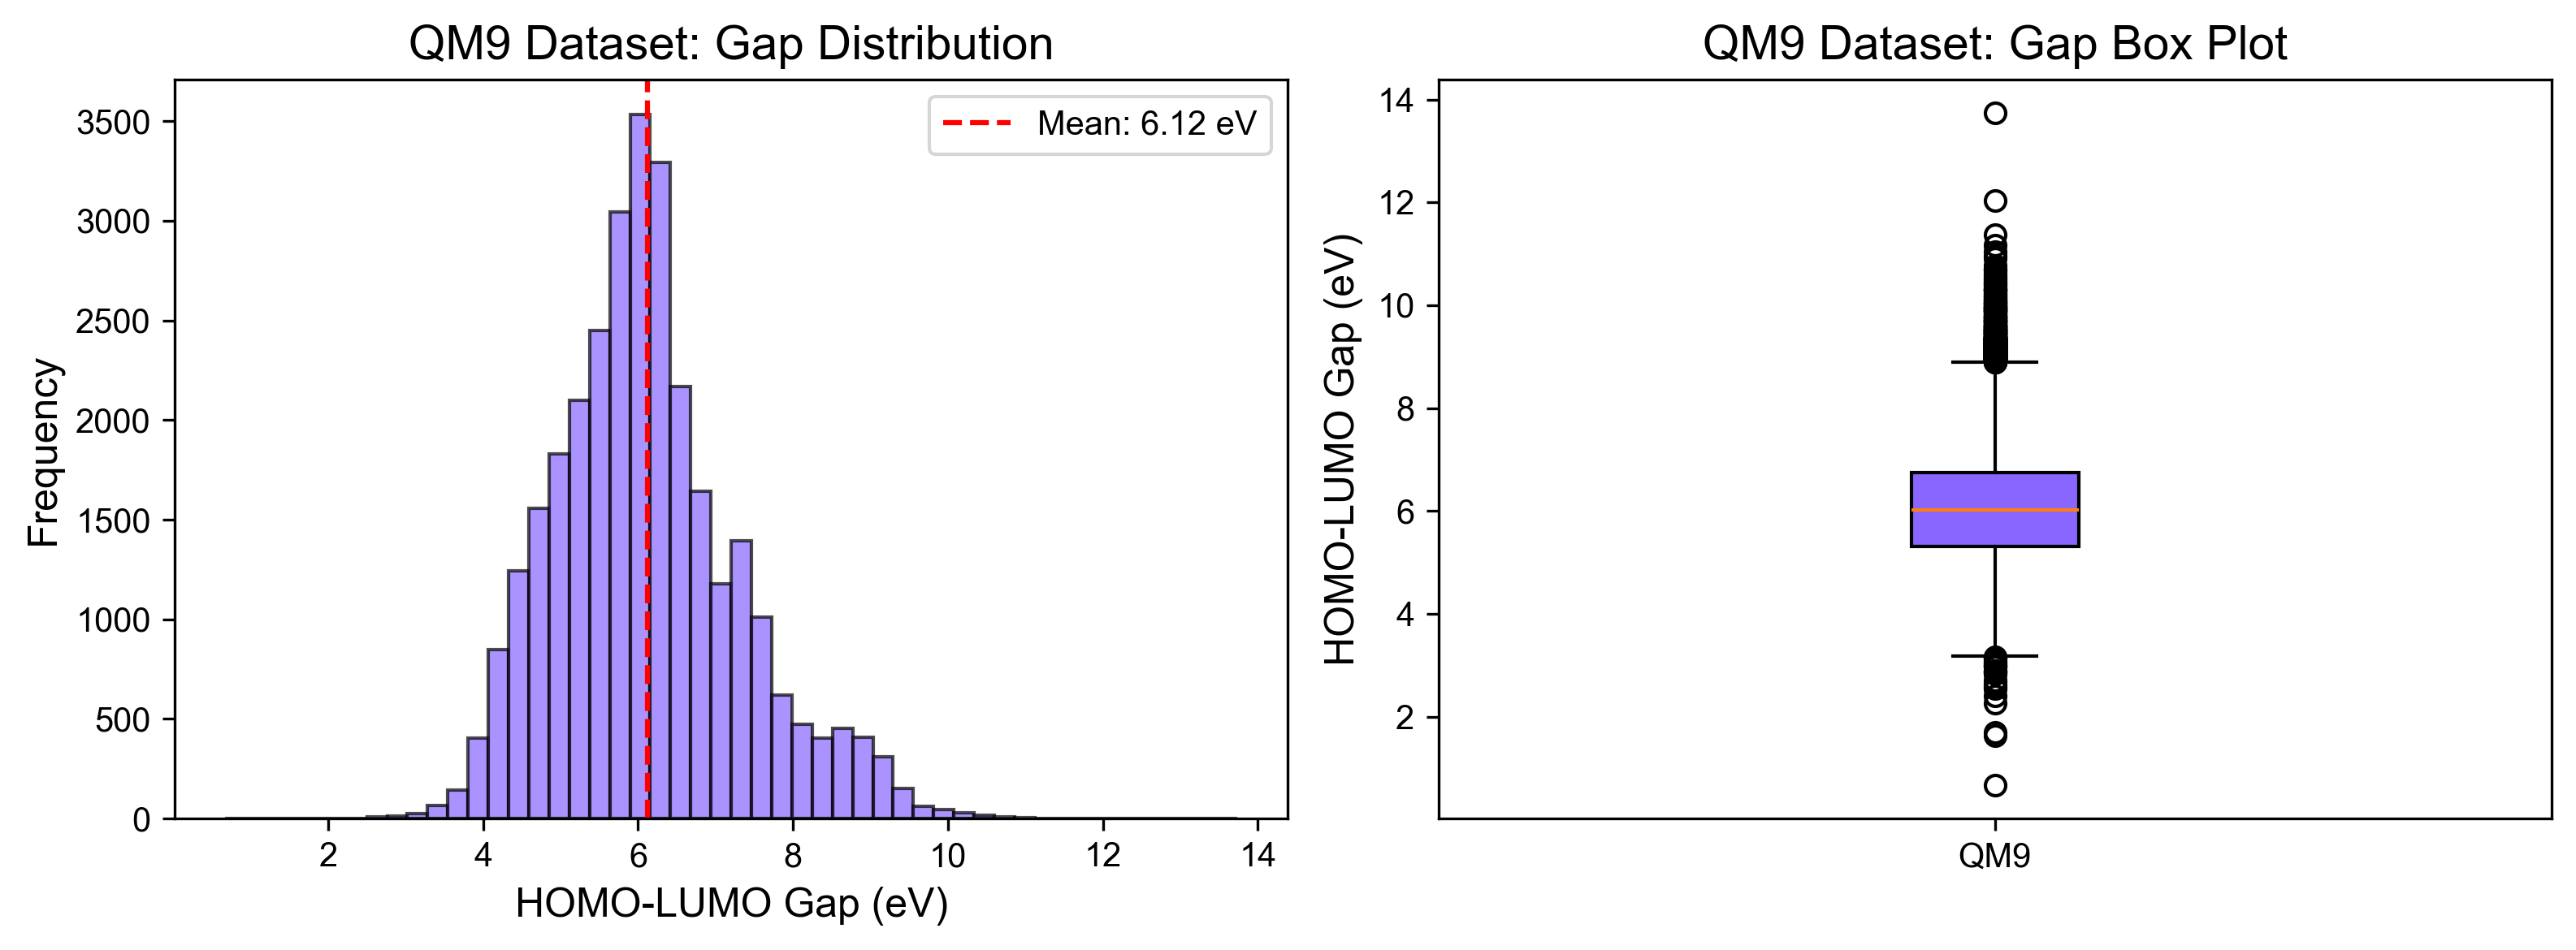


Gap Statistics:
count    30937.000000
mean         6.117798
std          1.195073
min          0.669400
25%          5.311662
50%          6.024601
75%          6.745702
max         13.736308
Name: gap, dtype: float64


In [4]:
# QM9 Gap 值分布可视化 (4:3 比例)
fig, axes = plt.subplots(1, 2, figsize=(10.67, 4))

# 直方图
axes[0].hist(qm9_df['gap'], bins=50, edgecolor='black', alpha=0.7, color='#8866FF')
axes[0].set_xlabel('HOMO-LUMO Gap (eV)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('QM9 Dataset: Gap Distribution')
axes[0].axvline(qm9_df['gap'].mean(), color='red', linestyle='--', label=f'Mean: {qm9_df["gap"].mean():.2f} eV')
axes[0].legend()

# 箱线图
bp = axes[1].boxplot(qm9_df['gap'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#8866FF')
axes[1].set_ylabel('HOMO-LUMO Gap (eV)')
axes[1].set_title('QM9 Dataset: Gap Box Plot')
axes[1].set_xticklabels(['QM9'])

plt.tight_layout()
plt.show()

print(f"\nGap Statistics:")
print(qm9_df['gap'].describe())

---

## 2. QAC 数据集的生成与处理

### 2.1 QAC 季铵离子简介

QAC 是季铵离子的通式，表示一个氮原子连接四个有机基团（烷基）并带有一个正电荷。本研究系统性地生成了所有可能的 QAC 化合物组合。

**化学结构**:
```
      R1
      |
R2 -- N+ -- R3
      |
      R4
```

其中 R1、R2、R3、R4 为烷基取代基。

### 2.2 化合物生成算法

#### 烷基基团库

生成器使用的烷基基团包括：

| 碳原子数 | 类型 | 示例 |
|----------|------|------|
| 1-17 | 直链烷基 | 甲基(C)、乙基(CC)、丙基(CCC)... |
| 3 | 支链烷基 | 异丙基: CC(C) |
| 4 | 支链烷基 | 异丁基: CC(C)C |
| 5 | 支链烷基 | 新戊基: CC(C)(C)C, 异戊基: CCC(C)C |
| 6-8 | 支链烷基 | 多种异构体 |

#### 组合生成策略

```python
from itertools import combinations_with_replacement

# 系统性枚举所有四个烷基的组合
for combo in combinations_with_replacement(alkyl_groups, 4):
    total_carbons = sum(alkyl[1] for alkyl in combo)
    if total_carbons <= max_carbons:
        smiles = build_qac_smiles(substituents)
        # 验证并保存有效化合物
```

#### SMILES 构建

季铵离子的 SMILES 格式：`[N+](R1)(R2)(R3)R4`

```python
def build_qac_smiles(substituents):
    main_chain = substituents[0]
    branches = substituents[1:]
    branch_part = ''.join(f'({r})' for r in branches)
    return f'[N+]{branch_part}{main_chain}'
```

### 2.3 PubChem 验证流水线

生成的化合物通过 PubChem 数据库进行三步验证：

| 步骤 | 功能 | 输出 |
|------|------|------|
| Step 1 | CID 验证 | 验证化合物在 PubChem 是否存在 |
| Step 2 | 属性查询 | 获取分子量、IUPAC 名称等 |
| Step 3 | 卤化盐 CAS 查询 | 获取对应卤化物的 CAS 号 |

### 2.4 数据集统计

In [5]:
# 加载 QAC 数据集统计信息
qac_base_meta_path = QAC_DIR / "dataset_qac_c20.csv.md5.json"
qac_cid_meta_path = QAC_DIR / "dataset_qac_c20_with_cid.csv.md5.json"
qac_final_meta_path = DATA_DIR / "qac.csv.md5.json"

with open(qac_base_meta_path, 'r') as f:
    qac_base_meta = json.load(f)

with open(qac_cid_meta_path, 'r') as f:
    qac_cid_meta = json.load(f)

with open(qac_final_meta_path, 'r') as f:
    qac_final_meta = json.load(f)

# QAC 处理统计
print("=" * 70)
print("QAC Dataset Generation and Processing Statistics")
print("=" * 70)

qac_stats = {
    "Stage": [
        "Initial Generation (max_carbons=20)",
        "After CID Validation",
        "After DFT Calculation (Final)"
    ],
    "Sample Count": [
        qac_base_meta['metadata']['total_compounds'],
        qac_cid_meta['metadata']['valid_cid_count'],
        qac_final_meta['metadata']['total_samples']
    ],
    "Description": [
        "Systematic enumeration of all possible QAC combinations",
        "Compounds existing in PubChem database",
        "Compounds with successful DFT Gap calculation"
    ]
}

display(pd.DataFrame(qac_stats))

QAC Dataset Generation and Processing Statistics


,Stage,Sample Count,Description
0,Initial Generation (max_carbons=20),6063,Systematic enumeration of all possible QAC com...
1,After CID Validation,6055,Compounds existing in PubChem database
2,After DFT Calculation (Final),124,Compounds with successful DFT Gap calculation


In [6]:
# 加载并展示 QAC 最终数据集
qac_df = pd.read_csv(DATA_DIR / "qac.csv")

print("=" * 70)
print("QAC 最终数据集预览（前10条）")
print("=" * 70)
display(qac_df.head(10))

print(f"\n数据集形状: {qac_df.shape}")
print(f"列名: {list(qac_df.columns)}")

QAC 最终数据集预览（前10条）


,SMILES,gap,mol_weight,num_rotatable_bonds,bertz_ct
0,C[N+](C)(C)C,10.096,74.147,4,15.509775
1,CC[N+](C)(C)C,9.051,88.174,5,29.793194
2,CCC[N+](C)(C)C,8.060,102.201,6,38.490225
3,CC[N+](C)(C)CC,9.022,102.201,6,38.000000
4,CC(C)C[N+](C)(C)C,7.976,116.228,7,54.928787
5,CCCC[N+](C)(C)C,7.426,116.228,7,47.548875
6,CCC[N+](C)(C)CC,8.261,116.228,7,53.058650
7,CC[N+](C)(CC)CC,9.115,116.228,7,42.793988
8,CC(C)(C)C[N+](C)(C)C,7.674,130.255,4,65.191883
9,CC(C)CC[N+](C)(C)C,7.313,130.255,8,64.597721



数据集形状: (124, 5)
列名: ['SMILES', 'gap', 'mol_weight', 'num_rotatable_bonds', 'bertz_ct']


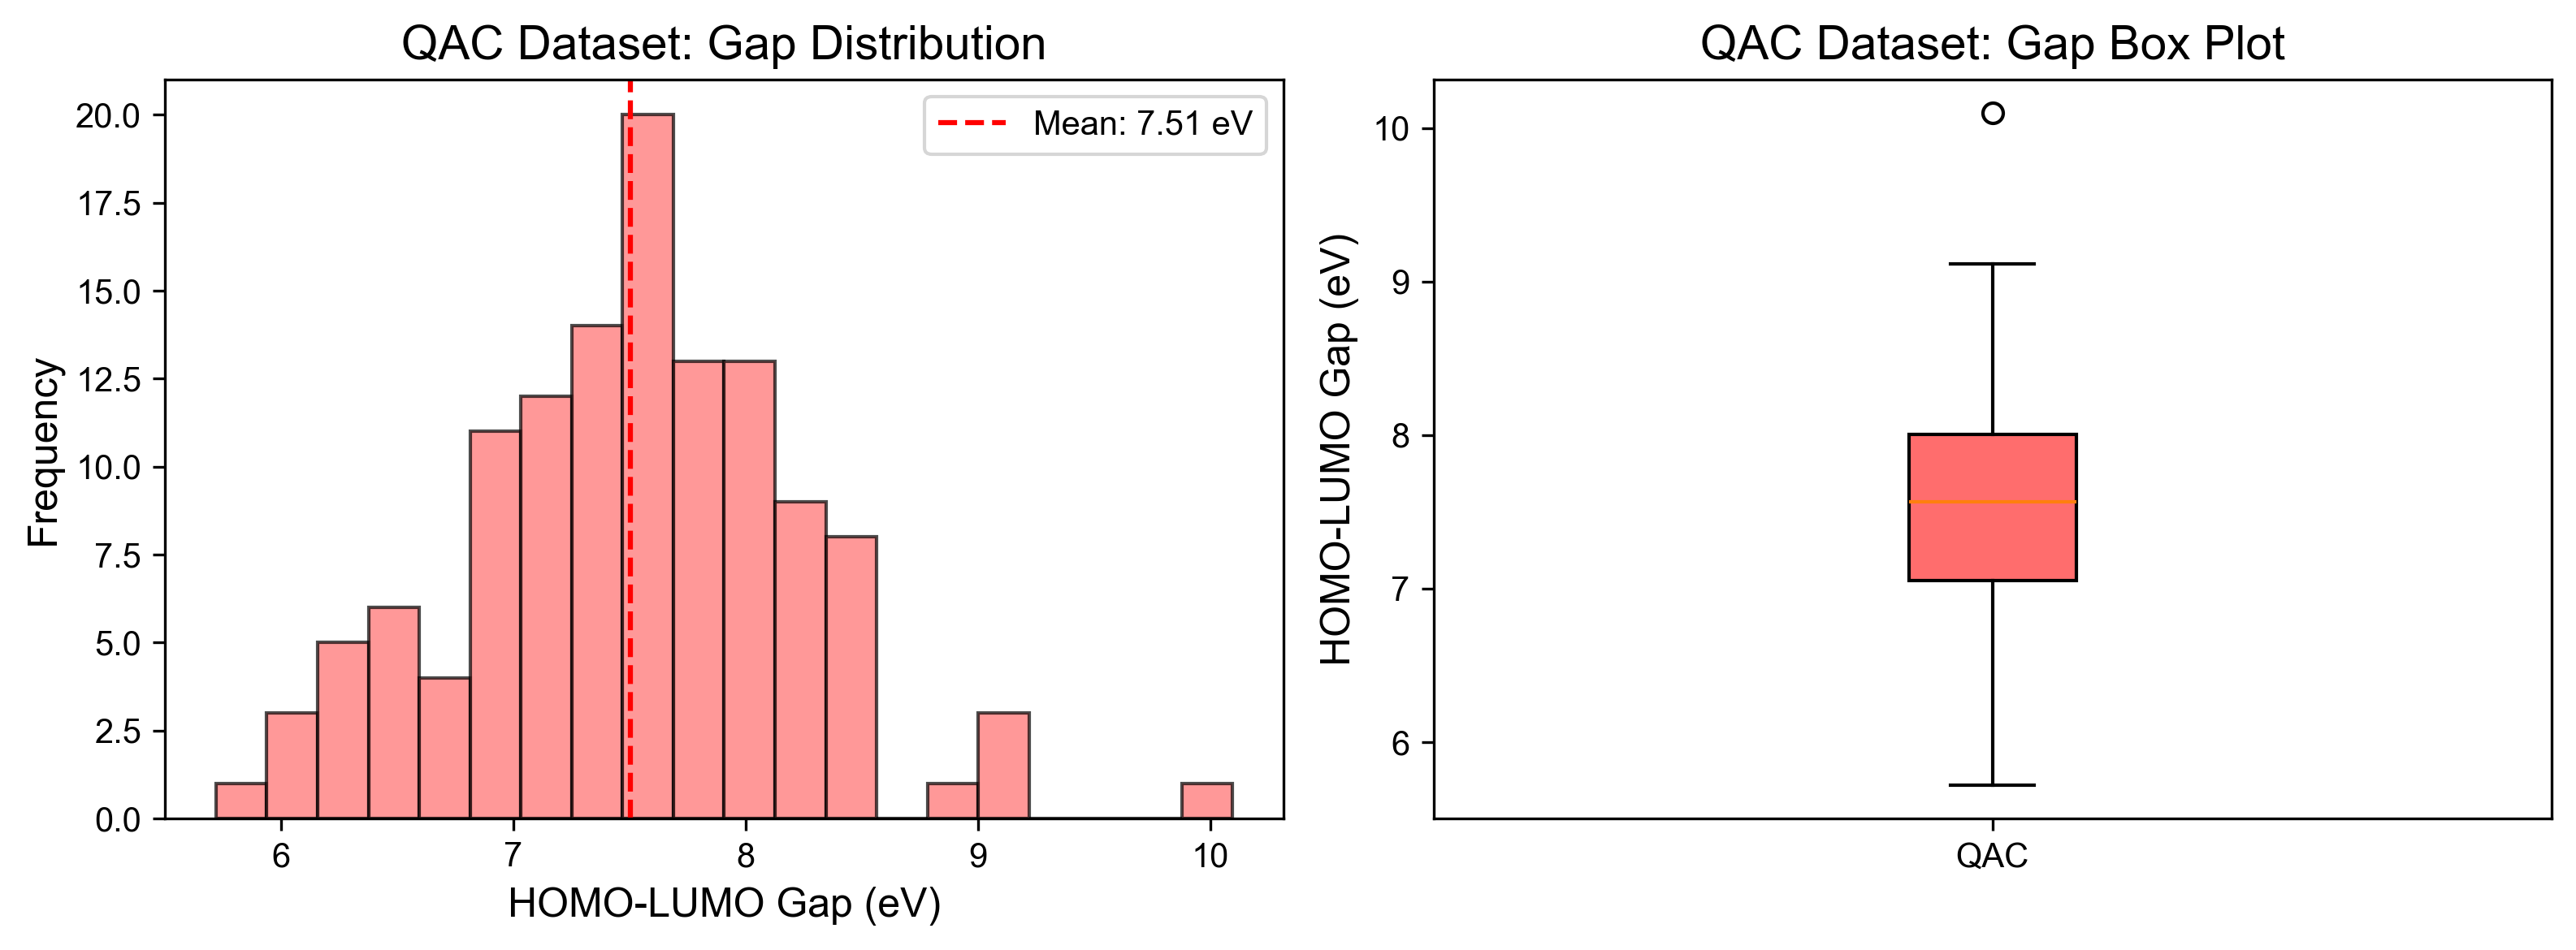


QAC Gap Statistics:
count    124.000000
mean       7.505331
std        0.733799
min        5.721000
25%        7.050000
50%        7.564500
75%        8.005500
max       10.096000
Name: gap, dtype: float64


In [7]:
# QAC Gap 值分布可视化 (4:3 比例)
fig, axes = plt.subplots(1, 2, figsize=(10.67, 4))

# 直方图
axes[0].hist(qac_df['gap'], bins=20, edgecolor='black', alpha=0.7, color='#FF6D6D')
axes[0].set_xlabel('HOMO-LUMO Gap (eV)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('QAC Dataset: Gap Distribution')
axes[0].axvline(qac_df['gap'].mean(), color='red', linestyle='--', label=f'Mean: {qac_df["gap"].mean():.2f} eV')
axes[0].legend()

# 箱线图
bp = axes[1].boxplot(qac_df['gap'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#FF6D6D')
axes[1].set_ylabel('HOMO-LUMO Gap (eV)')
axes[1].set_title('QAC Dataset: Gap Box Plot')
axes[1].set_xticklabels(['QAC'])

plt.tight_layout()
plt.show()

print(f"\nQAC Gap Statistics:")
print(qac_df['gap'].describe())

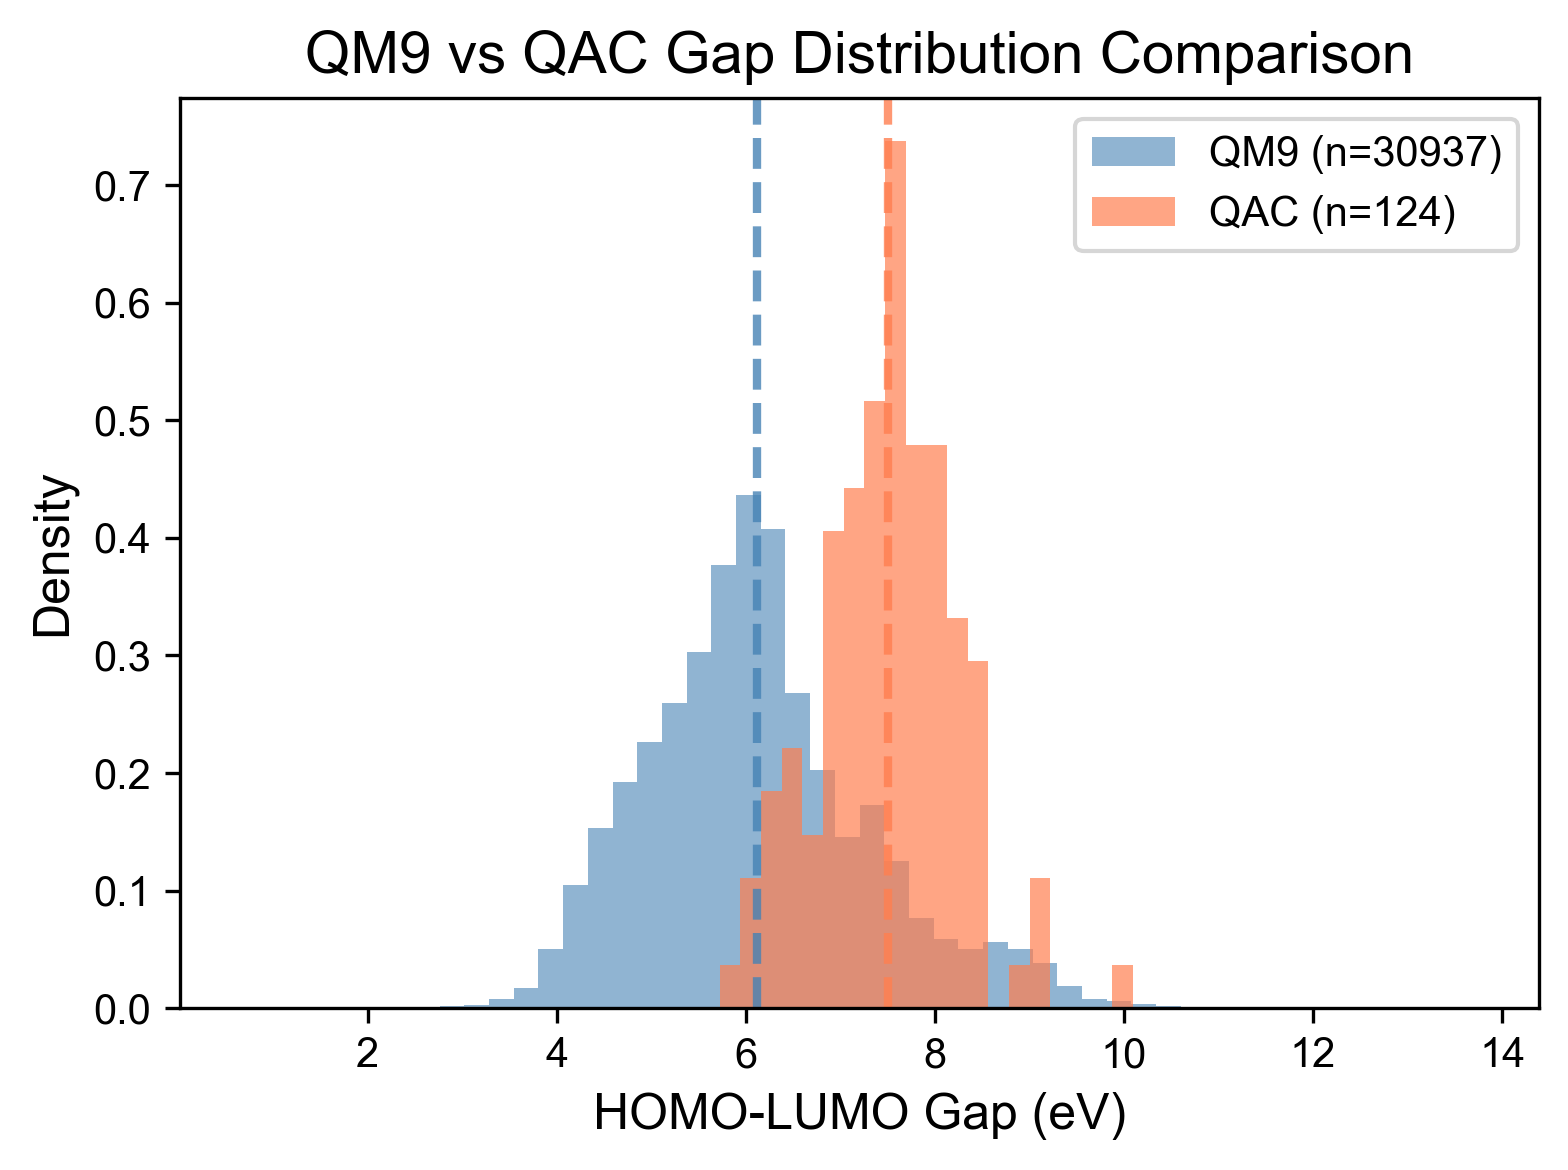


QM9 vs QAC Dataset Comparison


,Dataset,Samples,Gap Mean (eV),Gap Std (eV),Gap Min (eV),Gap Max (eV)
0,QM9,30937,6.118,1.195,0.669,13.736
1,QAC,124,7.505,0.734,5.721,10.096


In [8]:
# QM9 与 QAC 数据集对比 (4:3 比例)
fig, ax = plt.subplots(figsize=(5.33, 4))

# 绘制两个数据集的直方图
ax.hist(qm9_df['gap'], bins=50, alpha=0.6, label=f'QM9 (n={len(qm9_df)})', color='steelblue', density=True)
ax.hist(qac_df['gap'], bins=20, alpha=0.7, label=f'QAC (n={len(qac_df)})', color='coral', density=True)

ax.set_xlabel('HOMO-LUMO Gap (eV)')
ax.set_ylabel('Density')
ax.set_title('QM9 vs QAC Gap Distribution Comparison')
ax.legend()
ax.axvline(qm9_df['gap'].mean(), color='steelblue', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(qac_df['gap'].mean(), color='coral', linestyle='--', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

# 统计对比表
comparison_stats = {
    "Dataset": ["QM9", "QAC"],
    "Samples": [len(qm9_df), len(qac_df)],
    "Gap Mean (eV)": [f"{qm9_df['gap'].mean():.3f}", f"{qac_df['gap'].mean():.3f}"],
    "Gap Std (eV)": [f"{qm9_df['gap'].std():.3f}", f"{qac_df['gap'].std():.3f}"],
    "Gap Min (eV)": [f"{qm9_df['gap'].min():.3f}", f"{qac_df['gap'].min():.3f}"],
    "Gap Max (eV)": [f"{qm9_df['gap'].max():.3f}", f"{qac_df['gap'].max():.3f}"],
}

print("\n" + "=" * 70)
print("QM9 vs QAC Dataset Comparison")
print("=" * 70)
display(pd.DataFrame(comparison_stats))

---

## 3. 模型输入的构成

### 3.1 分子图表示

本研究采用图神经网络（GNN）进行 Gap 预测，将分子表示为图结构：

- **节点 (Nodes)**: 原子
- **边 (Edges)**: 化学键
- **图级属性**: 全局分子描述符

### 3.2 节点特征 (Node Features)

每个原子节点包含 **9 维** 特征向量：

| 特征 | 维度 | 说明 |
|------|------|------|
| 原子类型 (One-Hot) | 4 | C, H, O, N 四种原子类型 |
| 3D 坐标 | 3 | x, y, z 空间坐标 |
| 形式电荷 | 1 | 原子的形式电荷 |
| 杂化类型 | 1 | sp, sp², sp³ 等杂化状态 |

```python
def _extract_atom_features(atom, conf):
    # 原子类型 one-hot 编码
    atom_type_onehot = [
        1 if atom_num == 6 else 0,  # C
        1 if atom_num == 1 else 0,  # H
        1 if atom_num == 8 else 0,  # O
        1 if atom_num == 7 else 0,  # N
    ]
    # 3D 坐标
    pos = conf.GetAtomPosition(atom.GetIdx())
    coords = [pos.x, pos.y, pos.z]
    # 形式电荷和杂化类型
    return atom_type_onehot + coords + [
        atom.GetFormalCharge(), 
        atom.GetHybridization().real
    ]
```

### 3.3 边特征 (Edge Features)

每条边包含 **1 维** 特征：

| 特征 | 说明 |
|------|------|
| 键类型 | 单键(1.0)、双键(2.0)、三键(3.0)、芳香键(1.5) |

### 3.4 全局分子描述符 (Global Features)

每个分子包含 **3 维** 全局特征向量：

| 特征 | 说明 | 计算方法 |
|------|------|----------|
| `mol_weight` | 分子量 | RDKit `Descriptors.MolWt()` |
| `num_rotatable_bonds` | 可旋转键数 | RDKit `CalcNumRotatableBonds()` |
| `bertz_ct` | Bertz 复杂度 | RDKit `GraphDescriptors.BertzCT()` |

```python
def compute_global_descriptors(mol):
    mol_no_h = Chem.RemoveHs(mol)
    return [
        Descriptors.MolWt(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        GraphDescriptors.BertzCT(mol_no_h),
    ]
```

### 3.5 图数据结构

使用 PyTorch Geometric 的 `Data` 对象封装：

```python
Data(
    x=atom_features,       # [num_atoms, 9] 节点特征
    edge_index=edges,      # [2, num_edges] 边索引
    edge_attr=bond_types,  # [num_edges, 1] 边特征
    u=global_features,     # [1, 3] 全局特征
    y=gap_value            # [1] 目标值
)
```

In [9]:
# 加载预处理数据集并展示特征维度
from src import PreparedGraphDataset

qm9_prepared = PreparedGraphDataset(DATA_DIR / "qm9_prepared.joblib")
qac_prepared = PreparedGraphDataset(DATA_DIR / "qac_prepared.joblib")

print("=" * 70)
print("模型输入特征维度")
print("=" * 70)

feature_info = {
    "特征类型": ["节点特征 (Node Features)", "边特征 (Edge Features)", "全局特征 (Global Features)"],
    "QM9 维度": [
        qm9_prepared.num_node_features,
        qm9_prepared.num_edge_features,
        qm9_prepared.num_global_features
    ],
    "QAC 维度": [
        qac_prepared.num_node_features,
        qac_prepared.num_edge_features,
        qac_prepared.num_global_features
    ]
}

display(pd.DataFrame(feature_info))

# 展示一个样本的结构
print("\n" + "=" * 70)
print("示例分子图结构 (QM9 第一个样本)")
print("=" * 70)
sample = qm9_prepared[0]
print(f"节点数 (原子数): {sample.x.shape[0]}")
print(f"节点特征形状: {sample.x.shape}")
print(f"边数 (键数 x 2): {sample.edge_index.shape[1]}")
print(f"边特征形状: {sample.edge_attr.shape}")
print(f"全局特征: {sample.u.numpy().flatten()}")
print(f"目标值 (Gap): {sample.y.item():.4f} eV")

Loading dataset: d:\Github\R4N_Gap_Predictor\data\qm9_prepared.joblib
Loaded: 30902 graph objects
Loading dataset: d:\Github\R4N_Gap_Predictor\data\qac_prepared.joblib
Loaded: 124 graph objects
模型输入特征维度


,特征类型,QM9 维度,QAC 维度
0,节点特征 (Node Features),9,9
1,边特征 (Edge Features),1,1
2,全局特征 (Global Features),3,3



示例分子图结构 (QM9 第一个样本)
节点数 (原子数): 5
节点特征形状: torch.Size([5, 9])
边数 (键数 x 2): 8
边特征形状: torch.Size([8, 1])
全局特征: [16.043  0.     0.   ]
目标值 (Gap): 13.7363 eV


---

## 4. 模型架构

### 4.1 整体架构

本研究采用基于 **图注意力网络 (GAT)** 的架构，支持每层独立配置维度，结合多层感知机 (MLP) 进行最终预测。

```
Input Graph
     │
     ▼
┌─────────────────┐
│   GAT Layers    │  ← 图注意力卷积层（每层可独立配置维度）
│  (Variable)     │     支持 1-8 倍基础单元（BASE_UNIT=16）
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│  Global Pool    │  ← Mean + Max 双池化
│ (Mean + Max)    │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│ Concat Global   │  ← 拼接全局描述符 (3维)
│   Features      │
└────────┬────────┘
         │
         ▼
┌─────────────────┐
│   MLP Layers    │  ← 全连接层（每层可独立配置维度）
│  (Variable)     │     支持 1-8 倍基础单元
└────────┬────────┘
         │
         ▼
    Gap Prediction
```

### 4.2 GAT 层详解

**图注意力卷积 (GATConv)**:

$$
\mathbf{x}'_i = \alpha_{i,i}\mathbf{\Theta}\mathbf{x}_{i} + \sum_{j \in \mathcal{N}(i)} \alpha_{i,j}\mathbf{\Theta}\mathbf{x}_{j}
$$

其中 $\alpha_{i,j}$ 是注意力系数：

$$
\alpha_{i,j} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^{\top}[\mathbf{\Theta}\mathbf{x}_i \| \mathbf{\Theta}\mathbf{x}_j]))}{\sum_{k \in \mathcal{N}(i) \cup \{i\}} \exp(\text{LeakyReLU}(\mathbf{a}^{\top}[\mathbf{\Theta}\mathbf{x}_i \| \mathbf{\Theta}\mathbf{x}_k]))}
$$

**多头注意力机制**: 使用多个注意力头并行计算，最后拼接结果。

**边特征支持**: 每个 GAT 层都支持边特征（键级特征），增强化学键信息的表达。

### 4.3 全局池化

采用 **Mean + Max** 双池化策略：

$$
\mathbf{h}_{\text{graph}} = [\text{MeanPool}(\mathbf{X}) \| \text{MaxPool}(\mathbf{X})]
$$

- **Mean Pool**: 捕获图的整体统计特性
- **Max Pool**: 捕获最显著的局部特征

### 4.4 模型特点

1. **灵活的层维度配置**: 每层 GAT 和 MLP 可独立设置输出维度（基础倍率 16 的 1-8 倍）
2. **边特征支持**: GAT 层支持边特征输入，编码化学键信息
3. **全局特征融合**: 在池化后拼接全局分子描述符
4. **正则化策略**: BatchNorm + Dropout + ELU 激活函数

### 4.5 超参数搜索

使用 **Optuna** 框架进行自动超参数优化：

| 参数 | 搜索范围 | 说明 |
|------|----------|------|
| GAT 层维度 | 16-128 (倍率 1-8) | 每层独立搜索 |
| MLP 层维度 | 16-128 (倍率 1-8) | 每层独立搜索 |
| GAT 层数 | 1-4 | - |
| MLP 层数 | 2-5 | - |
| 注意力头数 | 2, 4, 8 | - |
| Dropout | 0.1-0.5 | - |
| 学习率 | 1e-4 - 1e-2 | 对数尺度 |
| 权重衰减 | 1e-6 - 1e-3 | 对数尺度 |

**搜索策略**:
- 采样器: TPE (Tree-structured Parzen Estimator)
- 剪枝器: Median Pruner
- 优化目标: 验证集 MAE

In [10]:
# 加载 Optuna 搜索结果
with open(PARAMS_DIR / "optuna_best_config.json", 'r') as f:
    optuna_config = json.load(f)

print("=" * 70)
print("Optuna 超参数搜索结果")
print("=" * 70)

# 搜索信息
print("\n【搜索配置】")
search_info = optuna_config['search_info']
search_config = {
    "参数": ["试验次数", "每次试验 Epoch", "早停耐心值", "批次大小", "随机种子"],
    "值": [
        search_info['n_trials'],
        search_info['num_epochs_per_trial'],
        search_info['patience'],
        search_info['batch_size'],
        search_info['random_seed']
    ]
}
display(pd.DataFrame(search_config))

# 数据集信息
print("\n【数据集划分】")
dataset_info = optuna_config['dataset_info']
dataset_split = {
    "数据集": ["训练集", "验证集", "测试集", "总计"],
    "样本数": [
        dataset_info['train_samples'],
        dataset_info['val_samples'],
        dataset_info['test_samples'],
        dataset_info['total_samples']
    ],
    "比例": ["70%", "15%", "15%", "100%"]
}
display(pd.DataFrame(dataset_split))

Optuna 超参数搜索结果

【搜索配置】


,参数,值
0,试验次数,200
1,每次试验 Epoch,200
2,早停耐心值,30
3,批次大小,64
4,随机种子,42



【数据集划分】


,数据集,样本数,比例
0,训练集,21631,70%
1,验证集,4635,15%
2,测试集,4636,15%
3,总计,30902,100%


In [11]:
# 最佳模型配置
print("=" * 70)
print("Best Model Architecture Configuration")
print("=" * 70)

best_params = optuna_config['best_params']

# 网络结构 - 动态生成表格
print("\n[Network Structure]")

# GAT 层信息
gat_dims = best_params['gat_dims']
mlp_dims = best_params['mlp_dims']

layers = []
dims = []
descriptions = []

# GAT 层
for i, dim in enumerate(gat_dims):
    layers.append(f"GAT Layer {i+1}")
    dims.append(dim)
    if i == 0:
        descriptions.append(f"Input: 9 -> Output: {dim}")
    else:
        descriptions.append(f"Input: {gat_dims[i-1]} -> Output: {dim}")

# MLP 层
mlp_input = gat_dims[-1] * 2 + 3  # Mean + Max 池化 + 3 个全局特征
for i, dim in enumerate(mlp_dims):
    layers.append(f"MLP Layer {i+1}")
    dims.append(dim)
    if i == 0:
        descriptions.append(f"Input: {mlp_input} -> Output: {dim}")
    else:
        descriptions.append(f"Input: {mlp_dims[i-1]} -> Output: {dim}")

# 输出层
layers.append("Output")
dims.append(1)
descriptions.append(f"Input: {mlp_dims[-1]} -> Output: 1 (Gap)")

arch_info = {
    "Layer Type": layers,
    "Output Dim": dims,
    "Description": descriptions
}
display(pd.DataFrame(arch_info))

# 超参数
print("\n[Training Hyperparameters]")
hyper_params = {
    "Parameter": ["Attention Heads", "Dropout Rate", "Learning Rate", "Weight Decay", "Total Parameters"],
    "Value": [
        best_params['num_heads'],
        best_params['dropout'],
        f"{best_params['lr']:.6f}",
        f"{best_params['weight_decay']:.6f}",
        f"{optuna_config['study_statistics']['model_parameters']:,}"
    ]
}
display(pd.DataFrame(hyper_params))

# 搜索统计
print("\n[Search Statistics]")
study_stats = {
    "Metric": ["Completed Trials", "Pruned Trials", "Best Val MAE"],
    "Value": [
        optuna_config['study_statistics']['n_completed_trials'],
        optuna_config['study_statistics']['n_pruned_trials'],
        f"{optuna_config['best_performance']['val_mae']:.4f} eV"
    ]
}
display(pd.DataFrame(study_stats))

Best Model Architecture Configuration

[Network Structure]


,Layer Type,Output Dim,Description
0,GAT Layer 1,96,Input: 9 -> Output: 96
1,GAT Layer 2,112,Input: 96 -> Output: 112
2,GAT Layer 3,96,Input: 112 -> Output: 96
3,MLP Layer 1,112,Input: 195 -> Output: 112
4,MLP Layer 2,112,Input: 112 -> Output: 112
5,MLP Layer 3,64,Input: 112 -> Output: 64
6,MLP Layer 4,128,Input: 64 -> Output: 128
7,MLP Layer 5,128,Input: 128 -> Output: 128
8,Output,1,Input: 128 -> Output: 1 (Gap)



[Training Hyperparameters]


,Parameter,Value
0,Attention Heads,8
1,Dropout Rate,0.1
2,Learning Rate,0.001531
3,Weight Decay,0.000680
4,Total Parameters,"91,777"



[Search Statistics]


,Metric,Value
0,Completed Trials,172
1,Pruned Trials,79
2,Best Val MAE,0.1630 eV


---

## 5. 模型预训练性能

### 5.1 预训练策略

**训练配置**:
- 数据集: QM9 (过滤后 30,902 个分子)
- 划分比例: 70% 训练 / 15% 验证 / 15% 测试
- 最大训练轮数: 1000 epochs
- 早停耐心值: 50 epochs
- 学习率调度: ReduceLROnPlateau (factor=0.5, patience=20)
- 损失函数: MAE (L1 Loss)
- 优化器: AdamW

### 5.2 训练曲线

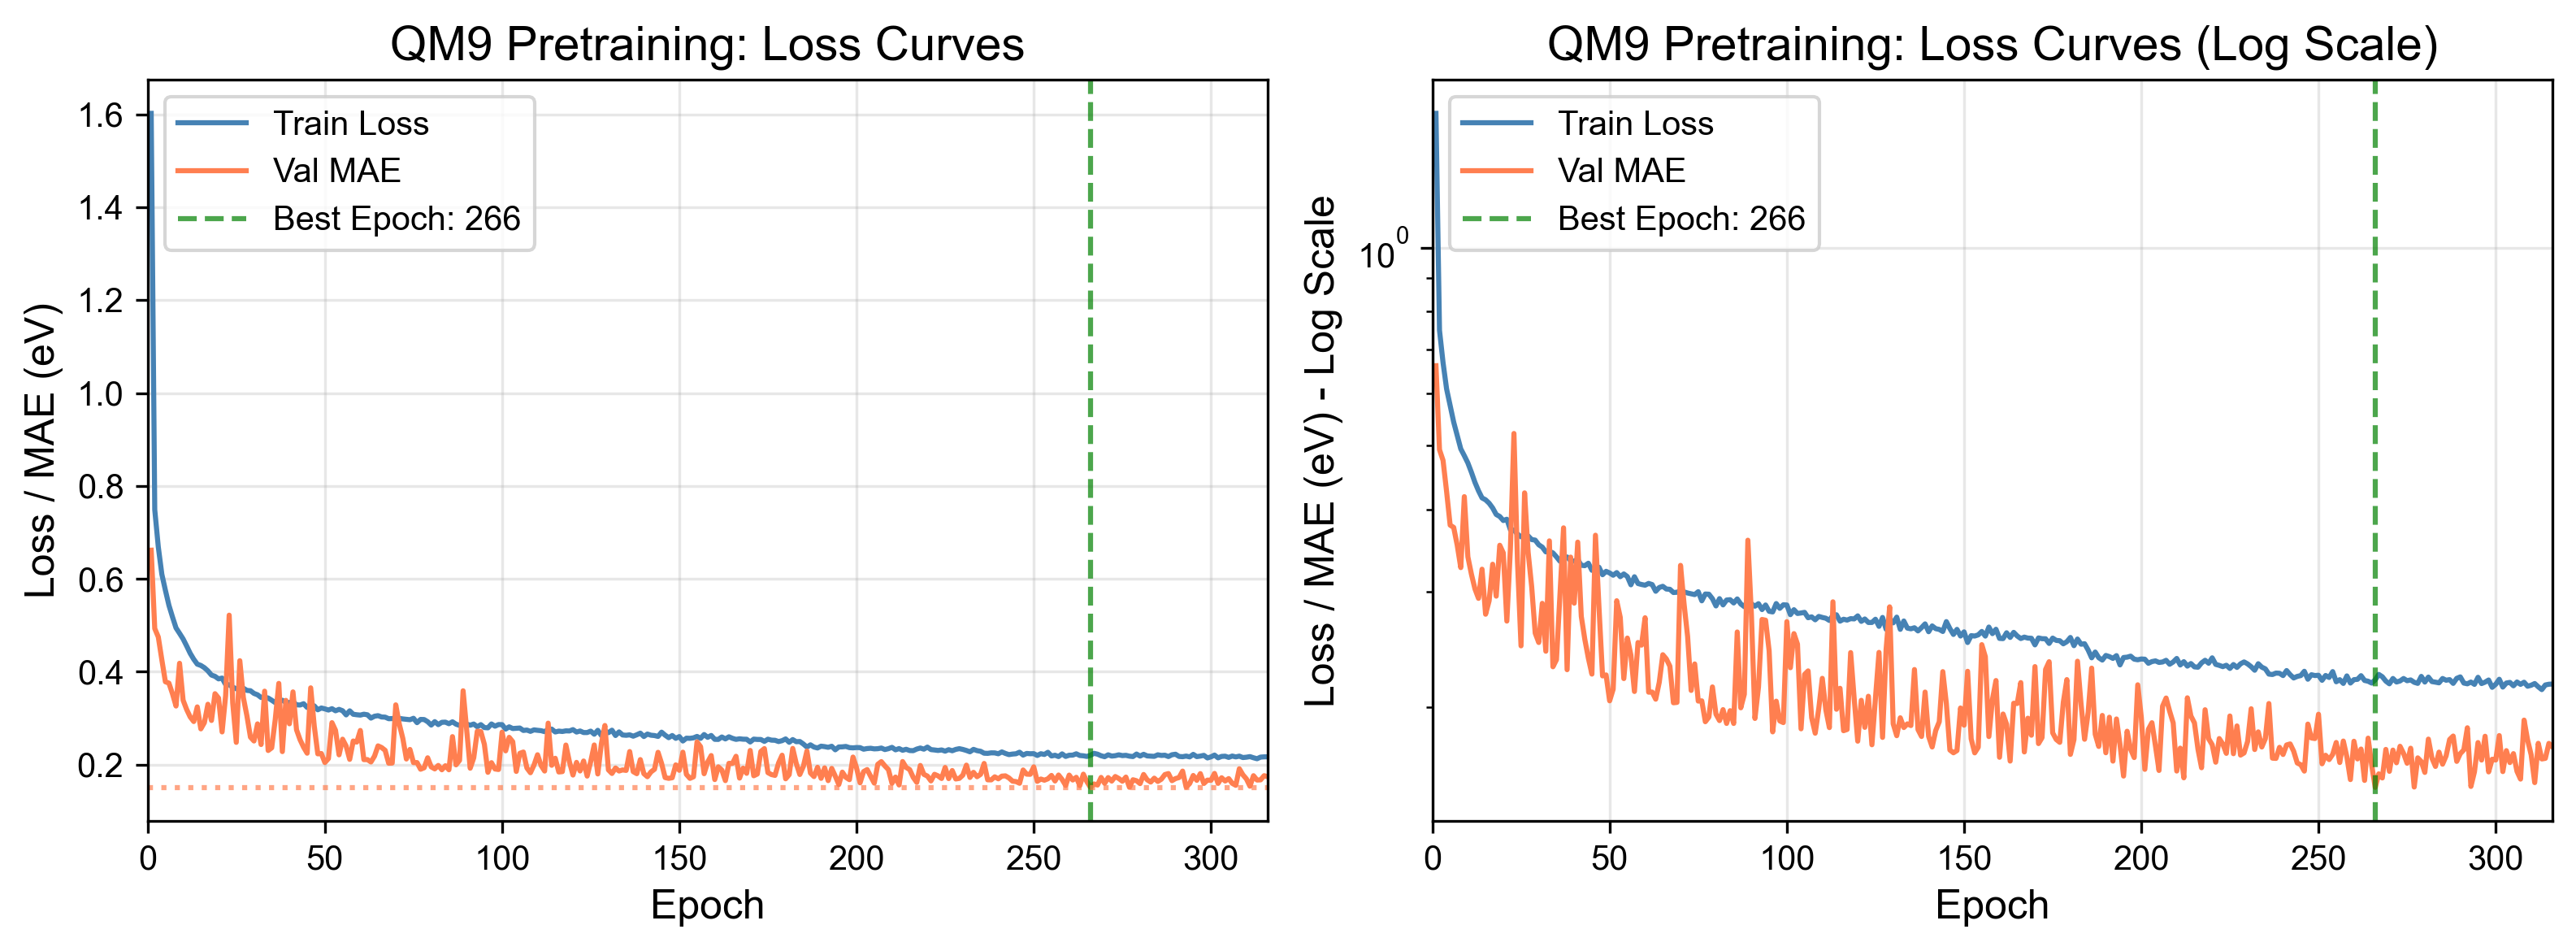

Total Training Epochs: 316
Best Model at Epoch: 266


In [12]:
# 加载预训练历史
pretrain_history = np.load(PARAMS_DIR / "qm9_pretrain_history.npz")

train_losses = pretrain_history['train_losses']
val_losses = pretrain_history['val_losses']
best_epoch = pretrain_history['best_epoch']
best_val_mae = pretrain_history['best_val_mae']
test_r2 = pretrain_history['test_r2']
test_mae = pretrain_history['test_mae']
test_rmse = pretrain_history['test_rmse']

# 绘制训练曲线 (4:3 比例)
fig, axes = plt.subplots(1, 2, figsize=(10.67, 4))

epochs = range(1, len(train_losses) + 1)

# 损失曲线
axes[0].plot(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
axes[0].plot(epochs, val_losses, label='Val MAE', color='coral', linewidth=1.5)
axes[0].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch: {best_epoch}')
axes[0].axhline(best_val_mae, color='coral', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / MAE (eV)')
axes[0].set_title('QM9 Pretraining: Loss Curves')
axes[0].legend()
axes[0].set_xlim([0, len(train_losses)])
axes[0].grid(True, alpha=0.3)

# 对数尺度
axes[1].semilogy(epochs, train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
axes[1].semilogy(epochs, val_losses, label='Val MAE', color='coral', linewidth=1.5)
axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch: {best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss / MAE (eV) - Log Scale')
axes[1].set_title('QM9 Pretraining: Loss Curves (Log Scale)')
axes[1].legend()
axes[1].set_xlim([0, len(train_losses)])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total Training Epochs: {len(train_losses)}")
print(f"Best Model at Epoch: {best_epoch}")

### 5.3 预训练性能指标

In [13]:
# 预训练性能汇总
print("=" * 70)
print("QM9 Pretrained Model Performance")
print("=" * 70)

pretrain_perf = {
    "Metric": ["R2 (Coefficient of Determination)", "MAE (Mean Absolute Error)", "RMSE (Root Mean Square Error)"],
    "Validation Set": [
        "-",
        f"{best_val_mae:.4f} eV",
        "-"
    ],
    "Test Set": [
        f"{test_r2:.4f}",
        f"{test_mae:.4f} eV",
        f"{test_rmse:.4f} eV"
    ]
}

display(pd.DataFrame(pretrain_perf))

# 过拟合分析
print("\n[Overfitting Analysis]")
overfitting_gap = test_mae - best_val_mae
print(f"MAE Difference (Test - Validation): {overfitting_gap:.4f} eV")
if overfitting_gap < 0.05:
    print("Status: Good generalization")
elif overfitting_gap < 0.1:
    print("Status: Acceptable")
else:
    print("Status: May need regularization")

QM9 Pretrained Model Performance


,Metric,Validation Set,Test Set
0,R2 (Coefficient of Determination),-,0.9621
1,MAE (Mean Absolute Error),0.1510 eV,0.1610 eV
2,RMSE (Root Mean Square Error),-,0.2318 eV



[Overfitting Analysis]
MAE Difference (Test - Validation): 0.0100 eV
Status: Good generalization


### 5.4 预训练模型小结

**预训练结果分析**:

1. **高精度预测**: 模型在 QM9 测试集上达到 R2 = 0.9621，MAE = 0.161 eV，表明模型能够准确学习 HOMO-LUMO Gap 的物理化学规律。

2. **良好泛化能力**: 测试集与验证集的 MAE 差异仅为 0.010 eV，说明模型没有过拟合，具有良好的泛化能力。

3. **学习曲线平稳**: 训练曲线显示模型在约 266 个 epoch 后趋于收敛，早停机制有效防止了过度训练。

4. **迁移学习基础**: 预训练模型学习了通用的分子结构-性质关系，为后续在 QAC 数据集上的微调奠定了基础。

---

## 6. 模型微调后性能

### 6.1 微调策略

**迁移学习方法**: 加载 QM9 预训练模型权重，在 QAC 数据集上继续训练

**微调配置**:
- 数据集: QAC (124 个分子)
- 训练样本: 约 80 个（用于交叉验证）
- 测试样本: 约 40 个（独立测试集）
- 交叉验证: 3 折
- 最大训练轮数: 1000 epochs
- 早停耐心值: 50 epochs
- 学习率: 1e-3（比预训练更小，避免破坏预训练权重）
- 批次大小: 8（小数据集使用较小批次）

### 6.2 交叉验证训练曲线

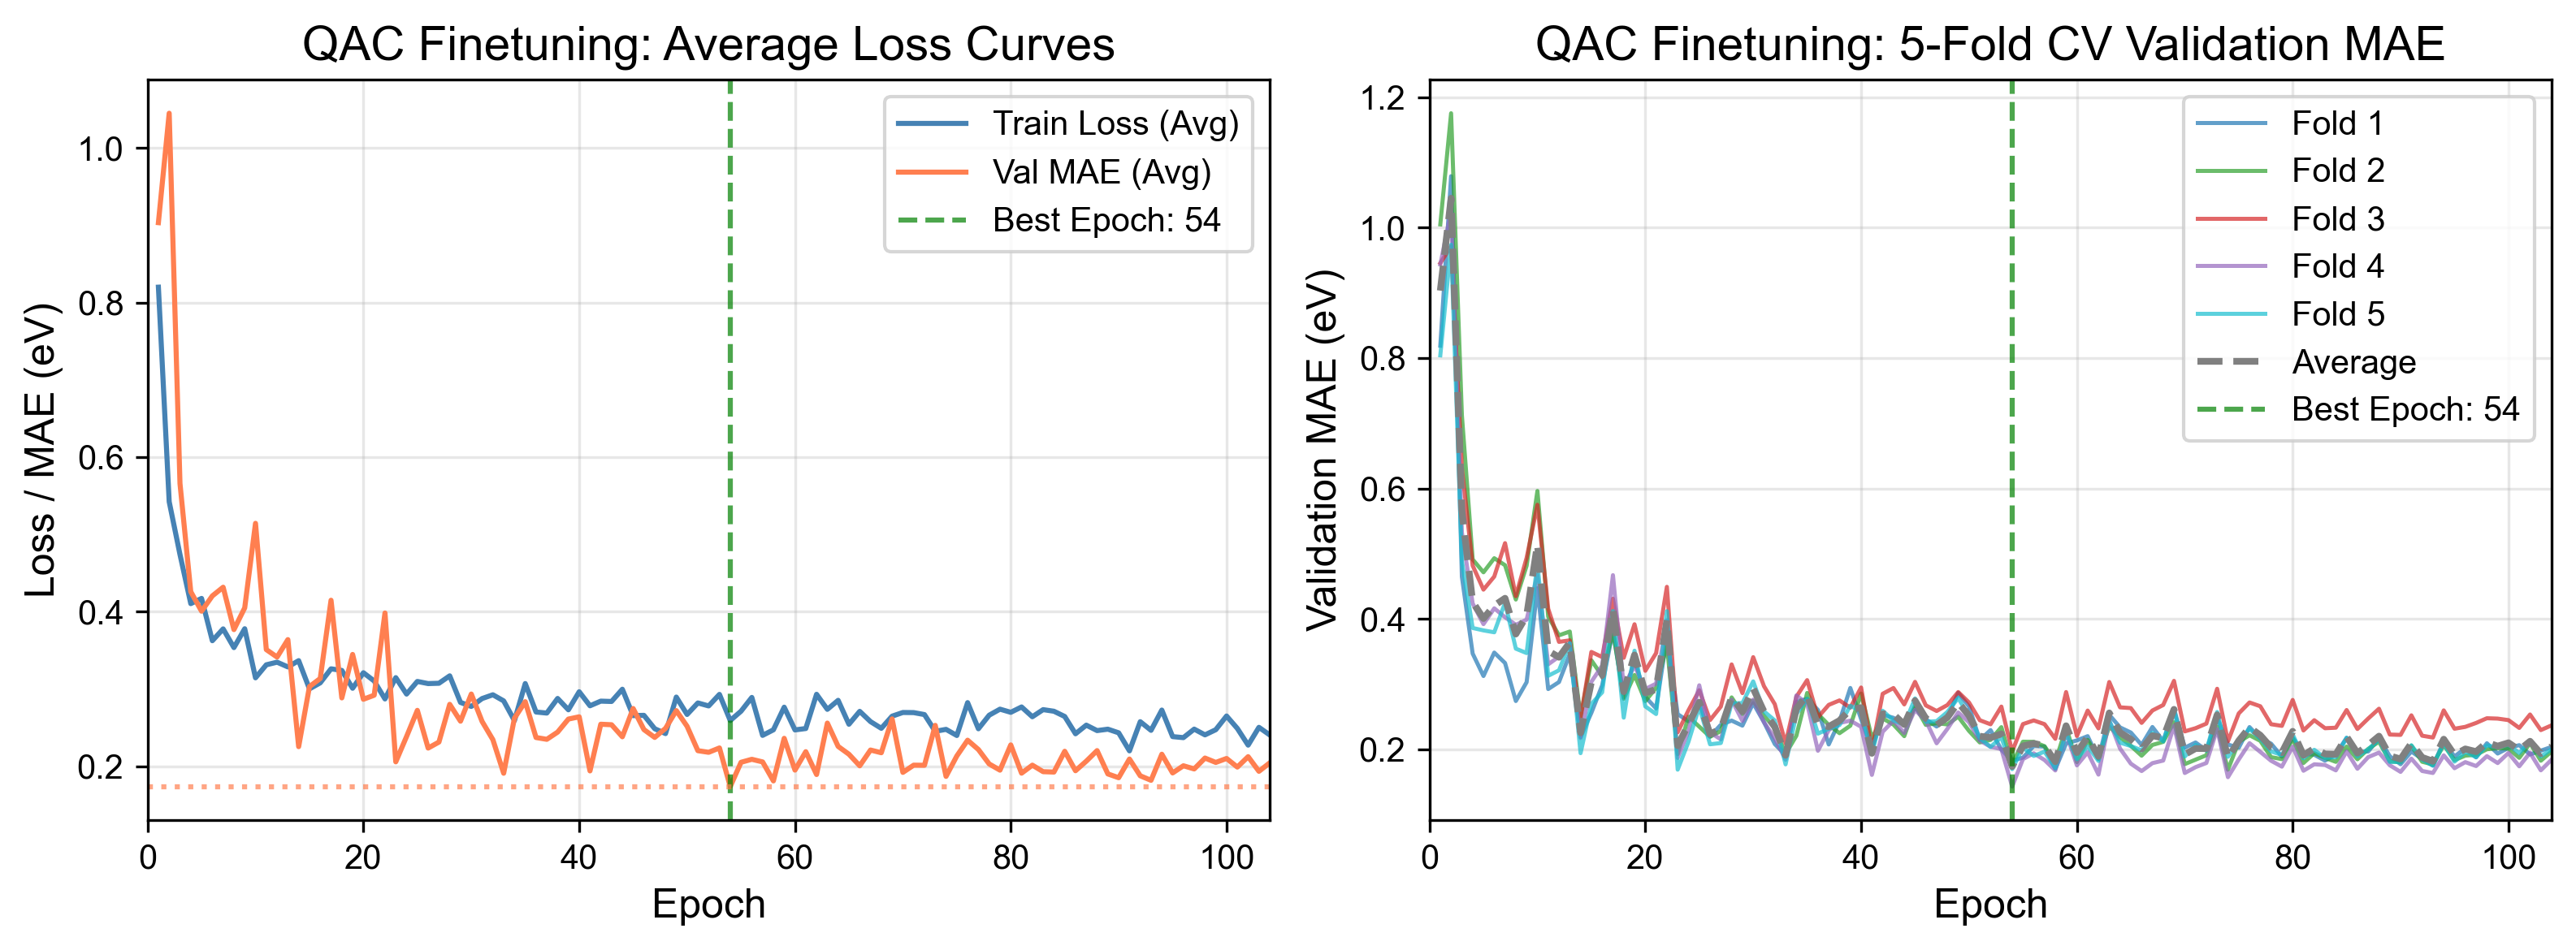

Total Training Epochs: 104
Best Model at Epoch: 54


In [14]:
# 加载微调历史
finetune_history = np.load(PARAMS_DIR / "qac_finetune_history.npz")

ft_train_losses = finetune_history['epoch_train_losses']
ft_val_losses = finetune_history['epoch_val_losses']
ft_fold_val_losses = finetune_history['fold_val_losses']
ft_best_epoch = int(finetune_history['best_epoch'])
ft_cv_avg_mae = float(finetune_history['cv_avg_mae'])
ft_test_mae = float(finetune_history['test_mae'])
ft_test_r2 = float(finetune_history['test_r2'])
ft_test_rmse = float(finetune_history['test_rmse'])

# 绘制微调训练曲线 (4:3 比例)
fig, axes = plt.subplots(1, 2, figsize=(10.67, 4))

epochs = range(1, len(ft_train_losses) + 1)

# 平均损失曲线
axes[0].plot(epochs, ft_train_losses, label='Train Loss (Avg)', color='steelblue', linewidth=1.5)
axes[0].plot(epochs, ft_val_losses, label='Val MAE (Avg)', color='coral', linewidth=1.5)
axes[0].axvline(ft_best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch: {ft_best_epoch}')
axes[0].axhline(ft_cv_avg_mae, color='coral', linestyle=':', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss / MAE (eV)')
axes[0].set_title('QAC Finetuning: Average Loss Curves')
axes[0].legend()
axes[0].set_xlim([0, len(ft_train_losses)])
axes[0].grid(True, alpha=0.3)

# 各折验证 MAE - 自定义颜色
n_folds = len(ft_fold_val_losses)
fold_colors = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#17becf', '#ff7f0e', '#8c564b', '#e377c2']
for fold_idx, fold_losses in enumerate(ft_fold_val_losses):
    axes[1].plot(epochs, fold_losses, label=f'Fold {fold_idx+1}', color=fold_colors[fold_idx % len(fold_colors)], alpha=0.7, linewidth=1.2)
axes[1].plot(epochs, ft_val_losses, label='Average', color='gray', linewidth=2, linestyle='--')
axes[1].axvline(ft_best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch: {ft_best_epoch}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation MAE (eV)')
axes[1].set_title(f'QAC Finetuning: {n_folds}-Fold CV Validation MAE')
axes[1].legend()
axes[1].set_xlim([0, len(ft_train_losses)])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total Training Epochs: {len(ft_train_losses)}")
print(f"Best Model at Epoch: {ft_best_epoch}")

### 6.3 微调后性能指标

In [15]:
# 微调性能汇总
print("=" * 70)
print("QAC Finetuned Model Performance")
print("=" * 70)

finetune_perf = {
    "Metric": ["R2 (Coefficient of Determination)", "MAE (Mean Absolute Error)", "RMSE (Root Mean Square Error)"],
    "Cross-Validation (3-Fold)": [
        "-",
        f"{ft_cv_avg_mae:.4f} eV",
        "-"
    ],
    "Independent Test Set": [
        f"{ft_test_r2:.4f}",
        f"{ft_test_mae:.4f} eV",
        f"{ft_test_rmse:.4f} eV"
    ]
}

display(pd.DataFrame(finetune_perf))

# 与预训练模型对比
print("\n" + "=" * 70)
print("Pretrain vs Finetune Performance Comparison")
print("=" * 70)

comparison = {
    "Model": ["QM9 Pretrain", "QAC Finetune"],
    "Dataset": ["QM9 (30,902)", f"QAC ({len(qac_df)})"],
    "Test R2": [f"{test_r2:.4f}", f"{ft_test_r2:.4f}"],
    "Test MAE (eV)": [f"{test_mae:.4f}", f"{ft_test_mae:.4f}"],
    "Test RMSE (eV)": [f"{test_rmse:.4f}", f"{ft_test_rmse:.4f}"]
}

display(pd.DataFrame(comparison))

QAC Finetuned Model Performance


,Metric,Cross-Validation (3-Fold),Independent Test Set
0,R2 (Coefficient of Determination),-,0.8065
1,MAE (Mean Absolute Error),0.1736 eV,0.2638 eV
2,RMSE (Root Mean Square Error),-,0.3042 eV



Pretrain vs Finetune Performance Comparison


,Model,Dataset,Test R2,Test MAE (eV),Test RMSE (eV)
0,QM9 Pretrain,"QM9 (30,902)",0.9621,0.1610,0.2318
1,QAC Finetune,QAC (124),0.8065,0.2638,0.3042


### 6.4 微调模型小结

**微调结果分析**:

1. **预测性能**: 微调模型在 QAC 测试集上达到 R2 = 0.8065，MAE = 0.264 eV，考虑到仅使用 124 个样本进行迁移学习，这是一个合理的结果。

2. **迁移学习有效性**: 通过在 QM9 大规模数据集上预训练，模型学习到了通用的分子结构-性质关系，成功迁移到 QAC 季铵离子预测任务。

3. **交叉验证稳定性**: 3 折交叉验证的平均 MAE 为 0.174 eV，各折之间的差异较小，表明模型训练稳定。

4. **小样本学习能力**: 仅使用约 80 个训练样本，模型就能够有效学习 QAC 化合物的 Gap 预测规律。

---

## 总结

### 研究贡献

1. **数据集构建**: 系统性地处理了 QM9 数据集（130,831 -> 30,937 个有效分子），并生成了 QAC 季铵离子数据集（6,063 个化合物，124 个完成 DFT 计算）。

2. **模型设计**: 提出了基于 GAT 的图神经网络架构，支持每层独立配置维度，结合全局分子描述符，有效捕获分子结构与 Gap 之间的关系。

3. **超参数优化**: 使用 Optuna 框架进行系统性超参数搜索，找到最优网络配置（3 层 GAT + 5 层 MLP，共 91,777 参数）。

4. **迁移学习策略**: 通过在 QM9 上预训练、QAC 上微调的两阶段训练策略，解决了 QAC 数据量不足的问题。

### 模型性能

| Stage | Dataset | R2 | MAE (eV) | RMSE (eV) |
|-------|---------|-----|----------|-----------|
| Pretrain | QM9 | 0.9621 | 0.161 | 0.232 |
| Finetune | QAC | 0.8065 | 0.264 | 0.304 |

### 未来工作

1. 扩大 QAC 数据集规模，完成更多化合物的 DFT 计算
2. 探索其他图神经网络架构（如 GIN、MPNN）
3. 引入更多分子描述符特征
4. 研究模型的可解释性，分析注意力权重与化学结构的关系

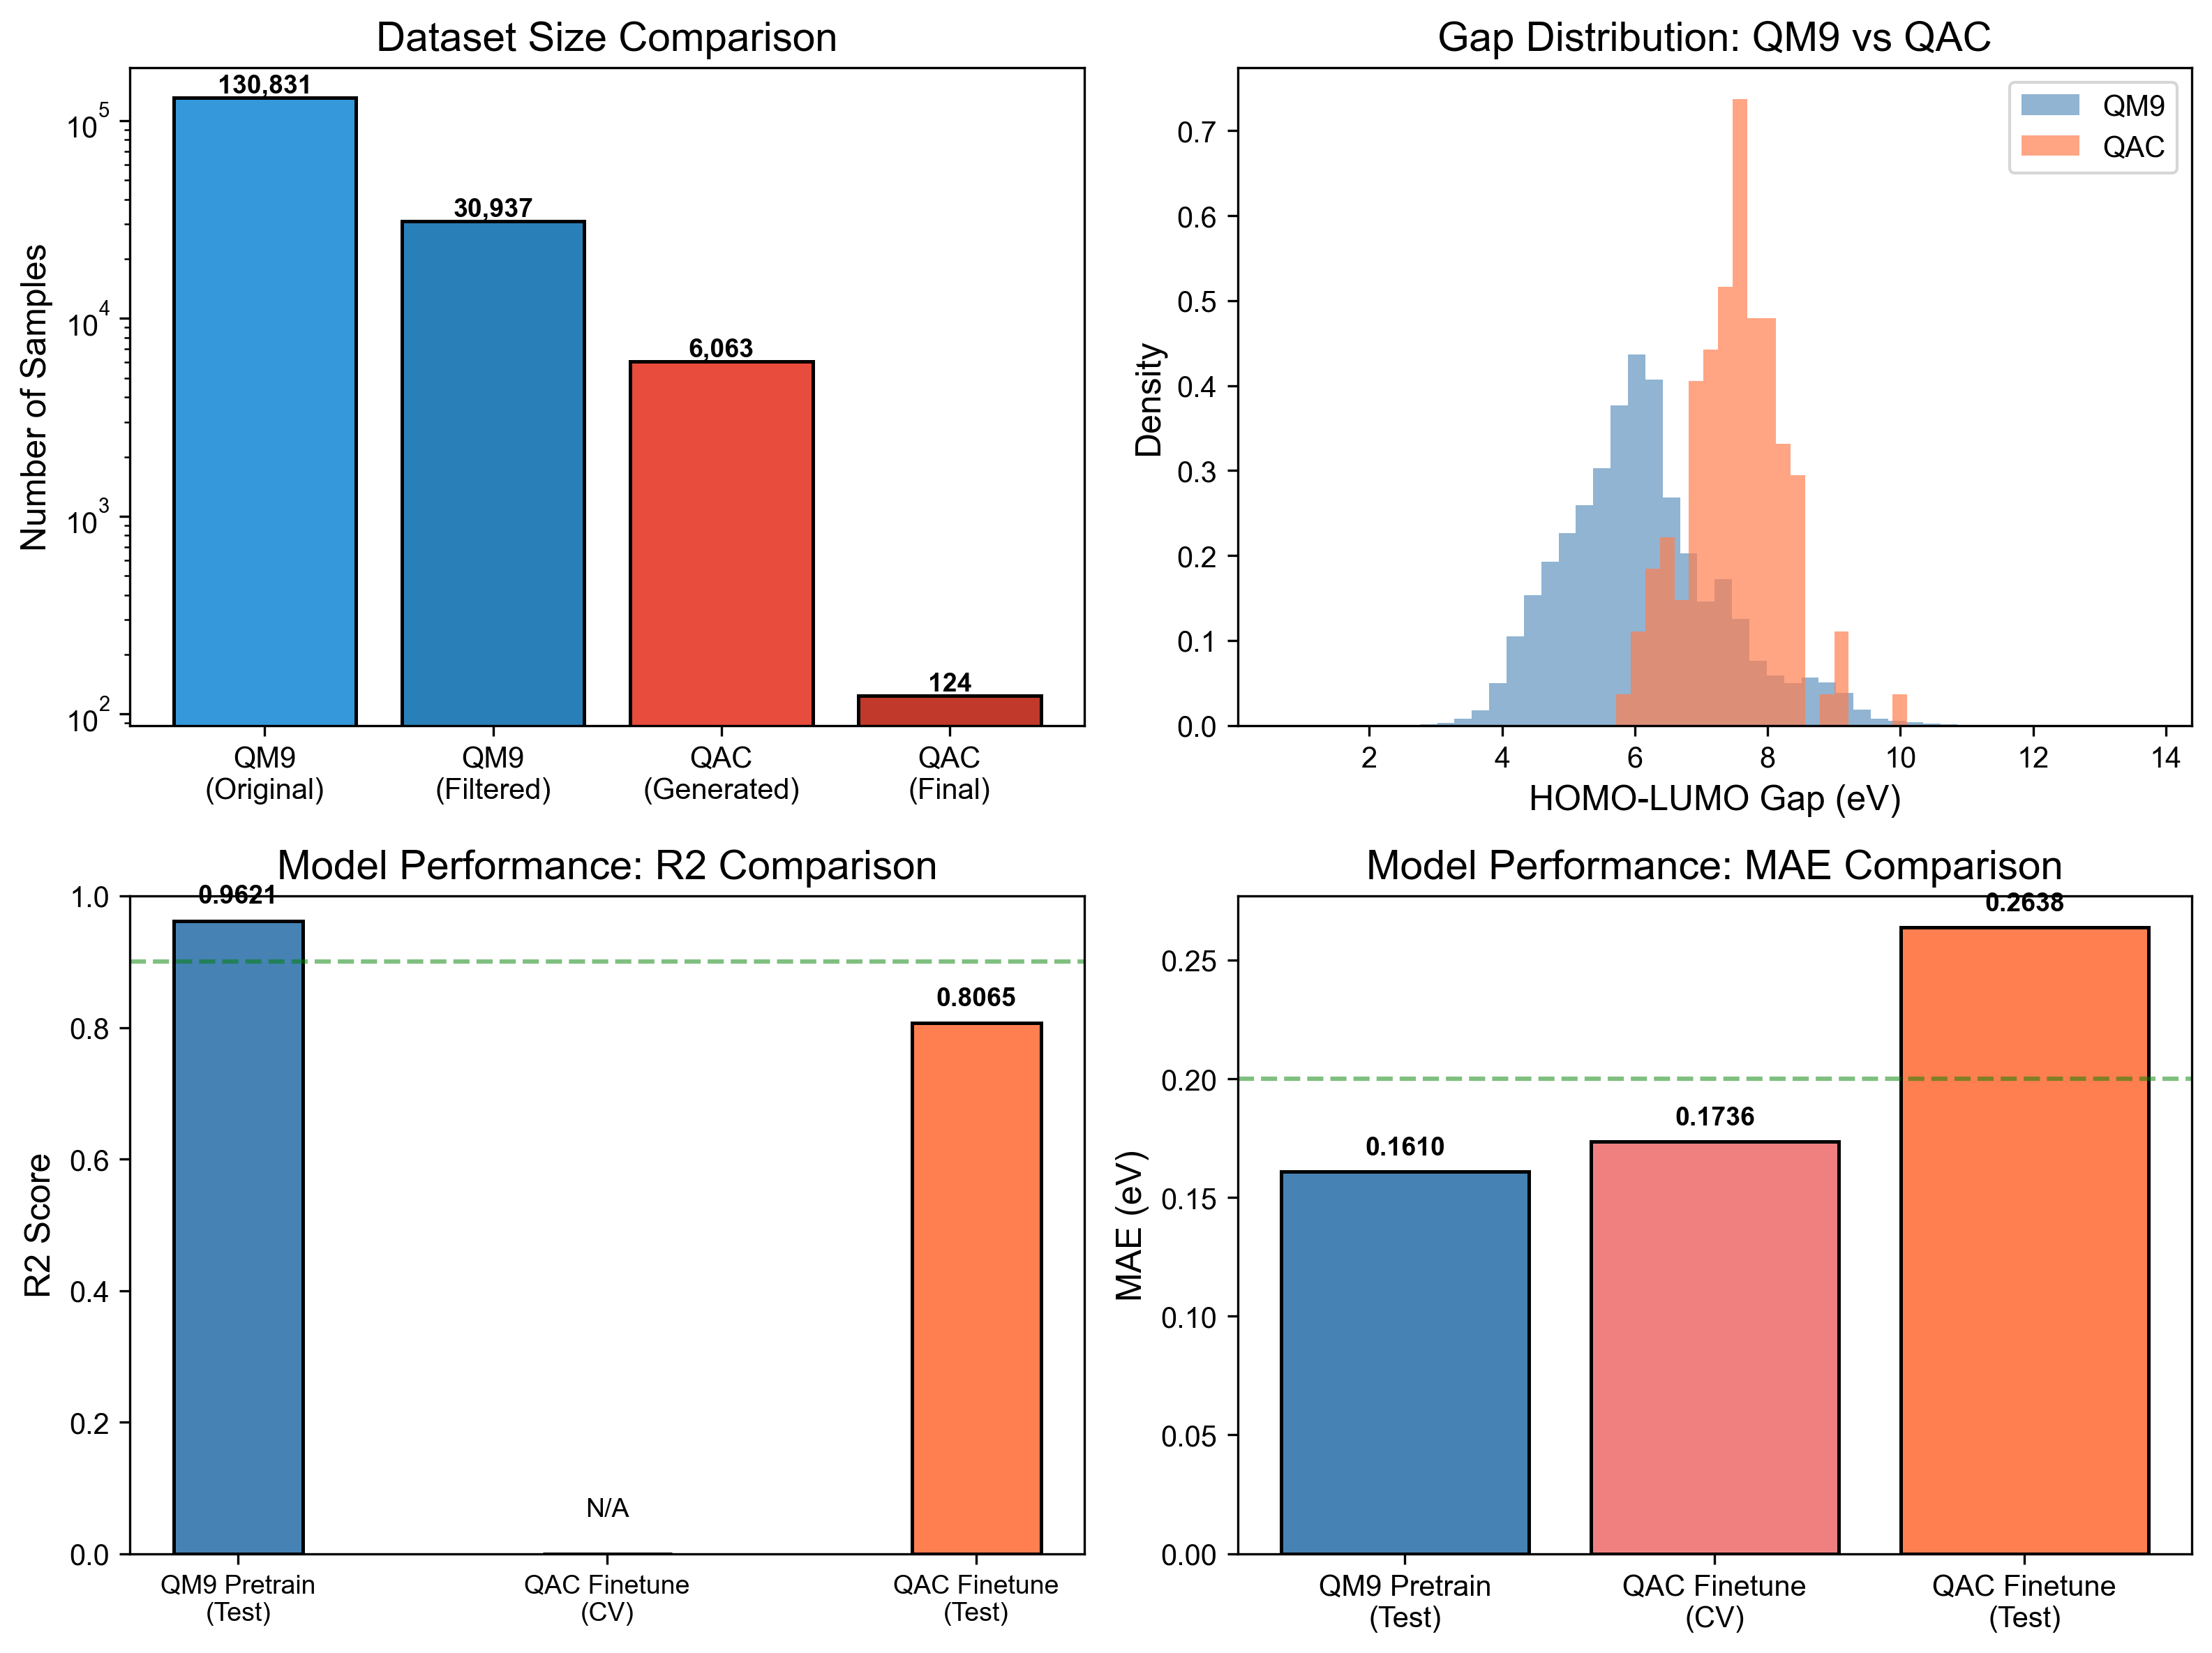

Summary figure saved to models/figures/report_summary.png


In [16]:
# 生成汇总可视化 (4:3 比例, 2x2 布局)
fig, axes = plt.subplots(2, 2, figsize=(10.67, 8))

# 1. 数据集规模对比
datasets = ['QM9\n(Original)', 'QM9\n(Filtered)', 'QAC\n(Generated)', 'QAC\n(Final)']
sizes = [130831, 30937, 6063, len(qac_df)]
colors = ['#3498db', '#2980b9', '#e74c3c', '#c0392b']
bars1 = axes[0, 0].bar(datasets, sizes, color=colors, edgecolor='black', linewidth=1.2)
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].set_title('Dataset Size Comparison')
axes[0, 0].set_yscale('log')
for bar, size in zip(bars1, sizes):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{size:,}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Gap 分布对比 (密度图)
axes[0, 1].hist(qm9_df['gap'], bins=50, alpha=0.6, label='QM9', color='steelblue', density=True)
axes[0, 1].hist(qac_df['gap'], bins=20, alpha=0.7, label='QAC', color='coral', density=True)
axes[0, 1].set_xlabel('HOMO-LUMO Gap (eV)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Gap Distribution: QM9 vs QAC')
axes[0, 1].legend()

# 3. 模型性能对比 (R2)
models = ['QM9 Pretrain\n(Test)', 'QAC Finetune\n(CV)', 'QAC Finetune\n(Test)']
r2_values = [test_r2, '-', ft_test_r2]
mae_values = [test_mae, ft_cv_avg_mae, ft_test_mae]
x = np.arange(len(models))
width = 0.35

# 只绘制有效的 R2 值
r2_plot = [test_r2, 0, ft_test_r2]
bars2 = axes[1, 0].bar(x, r2_plot, width, color=['steelblue', 'gray', 'coral'], edgecolor='black', linewidth=1.2)
axes[1, 0].set_ylabel('R2 Score')
axes[1, 0].set_title('Model Performance: R2 Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, fontsize=9)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].axhline(0.9, color='green', linestyle='--', alpha=0.5, label='R2 = 0.9')
for i, (bar, val) in enumerate(zip(bars2, r2_plot)):
    if val > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', 
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
    else:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, 0.05, 'N/A', 
                        ha='center', va='bottom', fontsize=9)

# 4. 模型性能对比 (MAE)
bars3 = axes[1, 1].bar(models, mae_values, color=['steelblue', 'lightcoral', 'coral'], edgecolor='black', linewidth=1.2)
axes[1, 1].set_ylabel('MAE (eV)')
axes[1, 1].set_title('Model Performance: MAE Comparison')
axes[1, 1].axhline(0.2, color='green', linestyle='--', alpha=0.5, label='MAE = 0.2 eV')
for bar, val in zip(bars3, mae_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.4f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(MODEL_DIR / "figures" / "report_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print("Summary figure saved to models/figures/report_summary.png")

---

## 附录: 数据处理流程图

```
                         Data Processing Pipeline
                                                            
【QM9 Dataset Processing】
                                                            
PyG QM9 Dataset --> Fluorine Filter --> SMILES Standardization --> Stereochemistry Filter
   (130,831)          (-24,061)                                       (-74,833)
                                                                          |
                                                                          v
                                                                    qm9_final.csv
                                                                      (30,937)
                                                                          |
                                                                          v
                                                                   Feature Computation
                                                                          |
                                                                          v
                                                                      qm9.csv
                                                                      (30,937)
                                                                          |
                                                                          v
                                                                  Graph Data Conversion
                                                                          |
                                                                          v
                                                                qm9_prepared.joblib
                                                                      (30,902)

【QAC Dataset Processing】

Alkyl Library --> QAC Combination --> SMILES Build --> RDKit Validation
                                                              |
                                                              v
                                                      dataset_qac_c20.csv
                                                           (6,063)
                                                              |
                                                              v
                                                      PubChem CID Validation
                                                              |
                                                              v
                                                   dataset_qac_c20_with_cid.csv
                                                           (6,055)
                                                              |
                                                              v
                                                        DFT Calculation
                                                              |
                                                              v
                                                          qac.csv
                                                            (124)
                                                              |
                                                              v
                                                      Graph Data Conversion
                                                              |
                                                              v
                                                    qac_prepared.joblib
                                                            (124)

【Model Training Pipeline】

qm9_prepared.joblib --> Optuna Hyperparameter Search --> Best Config
       |                    (200 trials)                      |
       |                                                      v
       +-----------------------------------------> QM9 Pretraining
                                                    (1000 epochs)
                                                         |
                                                         v
                                                  qm9_pretrained.pt
                                                         |
qac_prepared.joblib --------------------------------------|
       |                                                 v
       +--------------------------------------> QAC Finetuning
                                                  (3-Fold CV)
                                                      |
                                                      v
                                               qac_finetuned.pt
```

---

*Report Generated: February 2026*

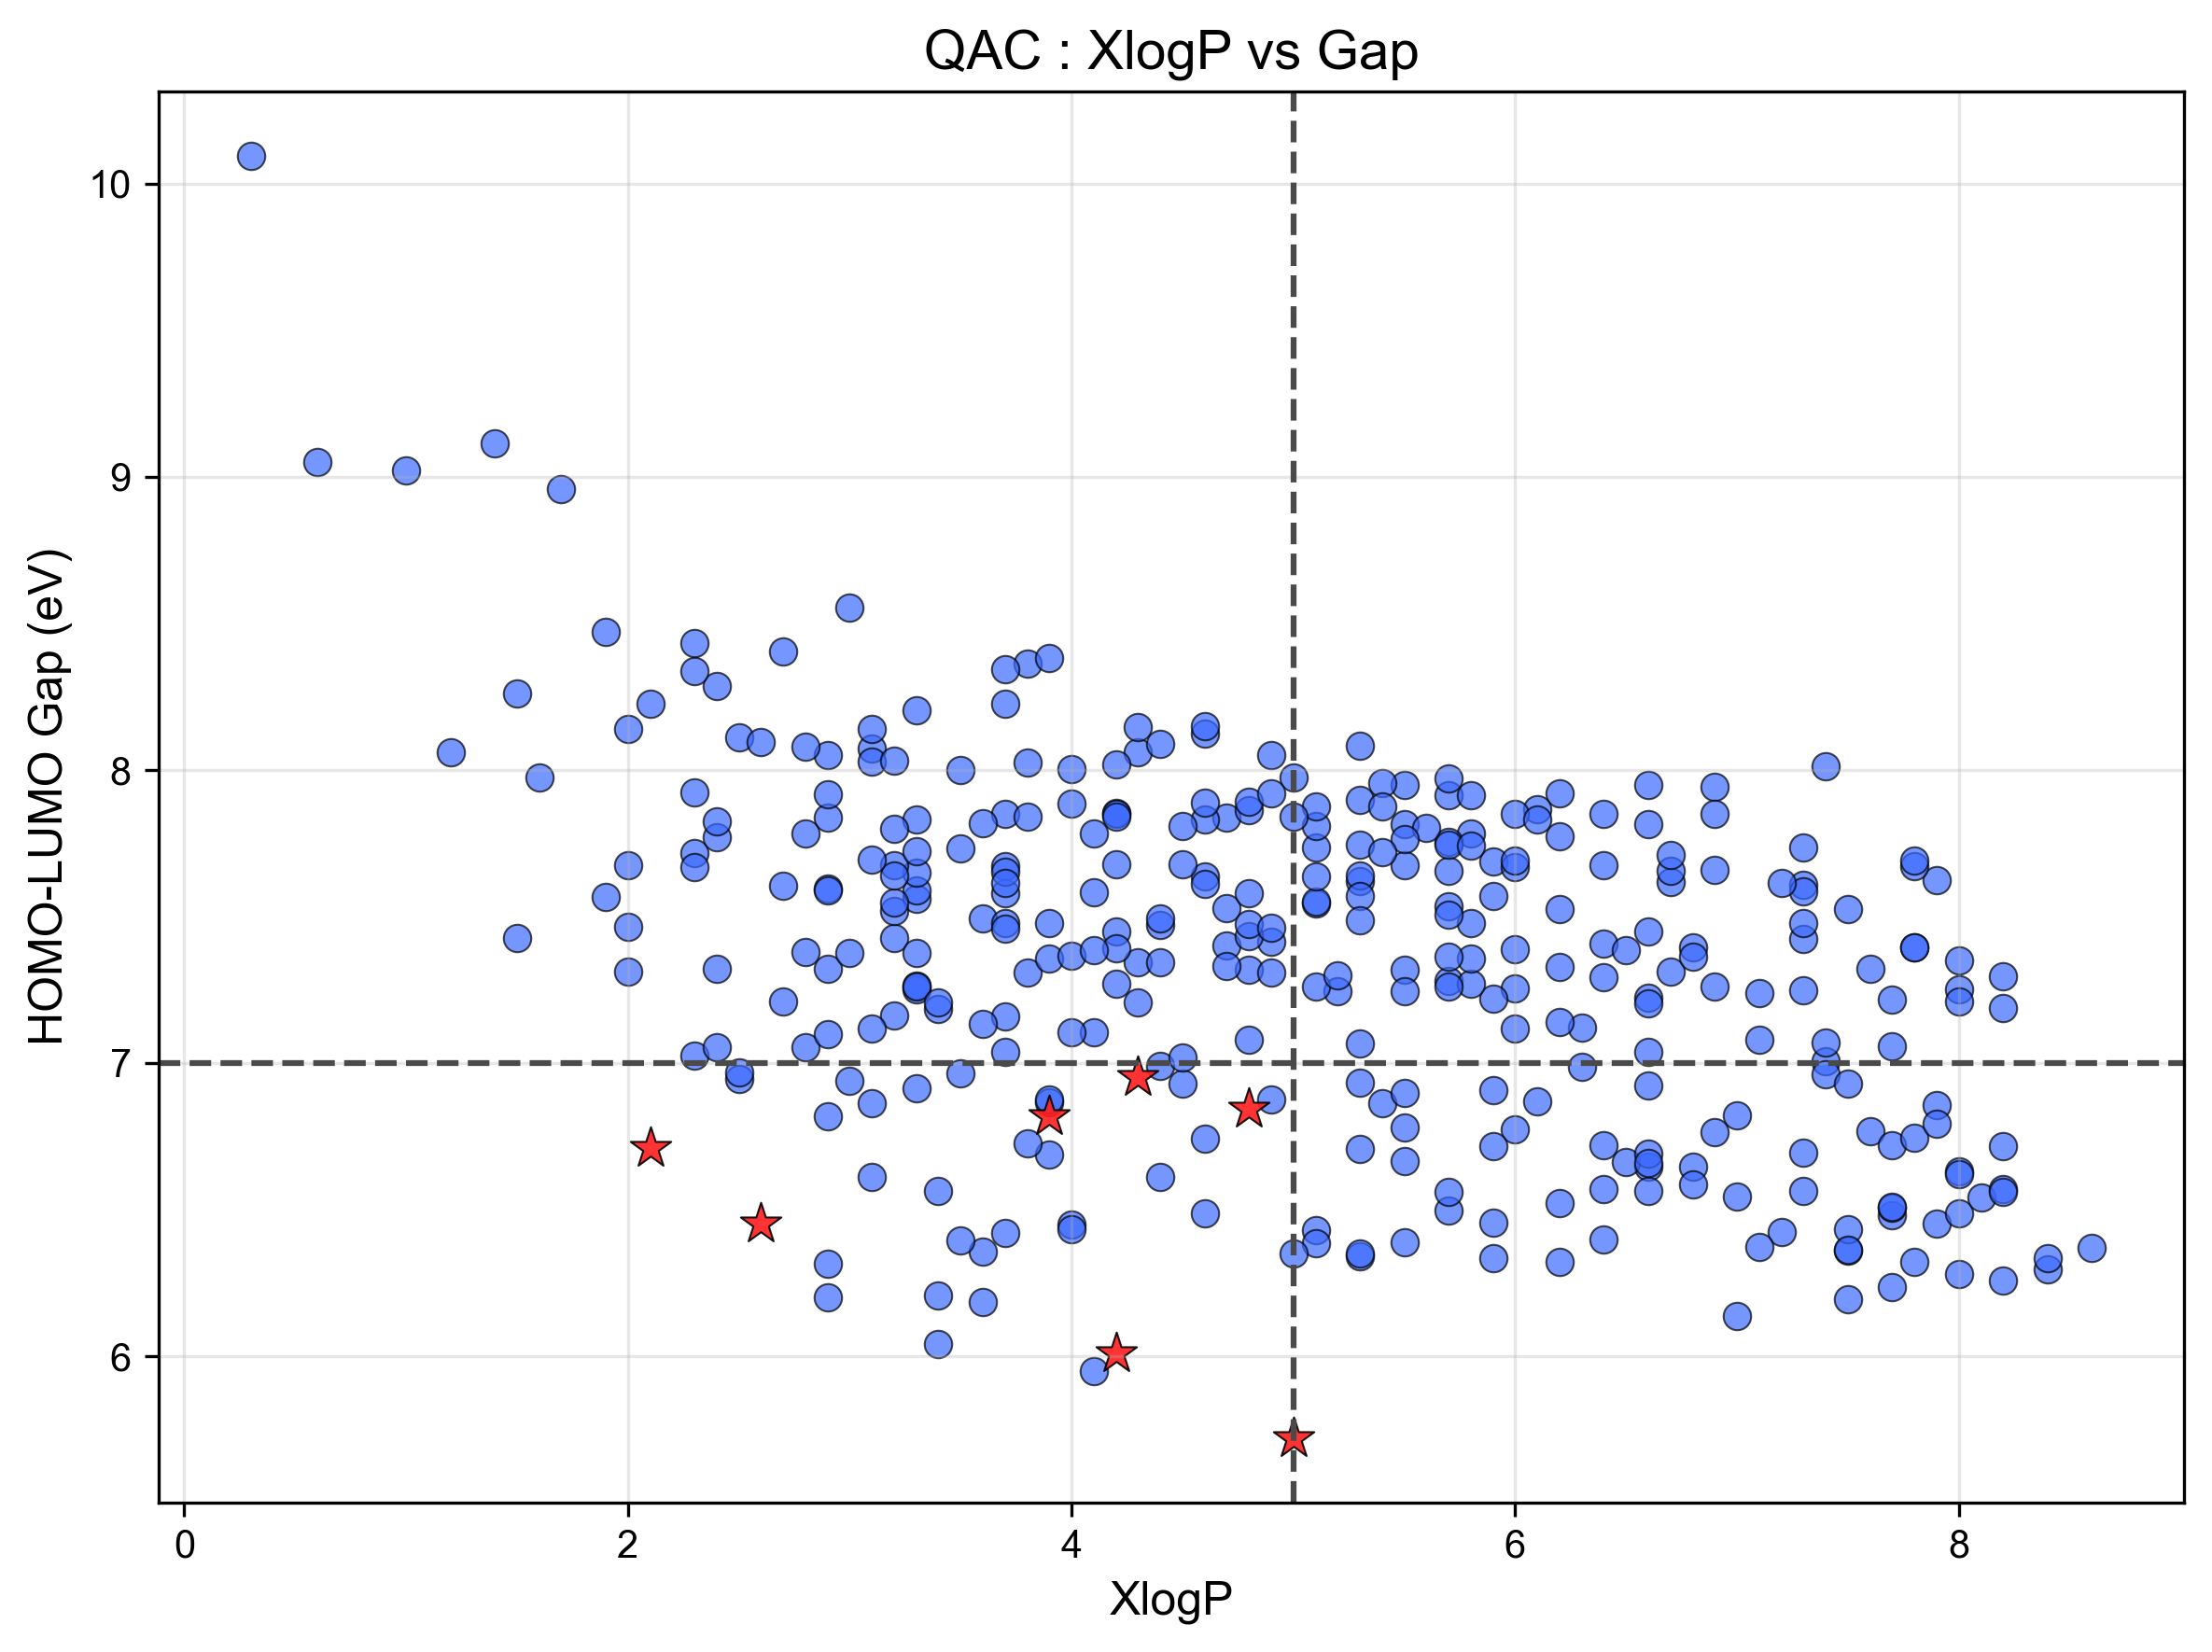

Total samples: 359
Special condition (xlogP<=5, Gap<=7, With CAS): 7
Others: 352

Special Compounds (xlogP<=5, Gap<=7, With CAS):
1. SMILES: CCCCC[N+](C)(C)C
   xlogP: 2.10, Gap: 6.71 eV
2. SMILES: CCCCCC[N+](C)(C)C
   xlogP: 2.60, Gap: 6.45 eV
3. SMILES: CCCCCCCC[N+](C)(C)C
   xlogP: 4.20, Gap: 6.01 eV
4. SMILES: CCCCCCCCC[N+](C)(C)C
   xlogP: 5.00, Gap: 5.72 eV
5. SMILES: CCCCCC[N+](C)(C)CCCC
   xlogP: 3.90, Gap: 6.82 eV
6. SMILES: CCCCCCC[N+](CC)(CC)CC
   xlogP: 4.30, Gap: 6.95 eV
7. SMILES: CCCCCCCC[N+](CC)(CC)CC
   xlogP: 4.80, Gap: 6.84 eV


In [ ]:
# 加载 qac_results.csv 并绘制 xlogP vs Gap 散点图
results_df = pd.read_csv(DATA_DIR / "qac_results.csv")

# 处理 gap 值：如果 gap 为空则使用 predicted_gap，都为空则删去
results_df['gap_final'] = results_df['gap'].fillna(results_df['predicted_gap'])
results_df = results_df.dropna(subset=['xlogp', 'gap_final'])

# 判断 Chloride_CAS 和 Bromide_CAS 是否至少有一个非空
has_cas = results_df['Chloride_CAS'].notna() | results_df['Bromide_CAS'].notna()

# 筛选条件：xlogp <= 5 且 gap <= 7 且有CAS
special_condition = (results_df['xlogp'] <= 5) & (results_df['gap_final'] <= 7) & has_cas

# 绘制散点图 (4:3 比例)
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制其他所有点（圆形，浅蓝色）
ax.scatter(results_df.loc[~special_condition, 'xlogp'], 
           results_df.loc[~special_condition, 'gap_final'],
           c="#3C6AFF", alpha=0.7, s=50, edgecolors='black', linewidth=0.5,
           marker='o')

# 绘制特殊条件的点（五角星，粉红色）
ax.scatter(results_df.loc[special_condition, 'xlogp'], 
           results_df.loc[special_condition, 'gap_final'],
           c="#FF1D1D", alpha=0.9, s=120, edgecolors='black', linewidth=0.5,
           marker='*')

ax.set_xlabel('XlogP')
ax.set_ylabel('HOMO-LUMO Gap (eV)')
ax.set_title('QAC : XlogP vs Gap')

# 在 xlogP=5 和 Gap=7 位置添加浅灰色虚线
ax.axvline(x=5, color='#8A8A8A', linestyle='--', linewidth=1)
ax.axhline(y=7, color='#8A8A8A', linestyle='--', linewidth=1)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total samples: {len(results_df)}")
print(f"Special condition (xlogP<=5, Gap<=7, With CAS): {special_condition.sum()}")
print(f"Others: {(~special_condition).sum()}")

# 输出五角星标记的化合物 SMILES
print("\n" + "=" * 70)
print("Special Compounds (xlogP<=5, Gap<=7, With CAS):")
print("=" * 70)
special_df = results_df.loc[special_condition, ['SMILES', 'xlogp', 'gap_final']].reset_index(drop=True)
for idx, row in special_df.iterrows():
    print(f"{idx+1}. SMILES: {row['SMILES']}")
    print(f"   xlogP: {row['xlogp']:.2f}, Gap: {row['gap_final']:.2f} eV")